In [3]:
import shap
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

# Charger le modèle et les données
model = joblib.load('../models/xgboost.pkl')
X_test = joblib.load('../data/X_test.pkl')
y_test = joblib.load('../data/y_test.pkl')
le = joblib.load('../models/label_encoder.pkl')

# Échantillon pour SHAP
X_sample = X_test[:500]

print(f"Shape X_sample : {X_sample.shape}")
print(f"Classes : {le.classes_}")
print("Chargement terminé ")

Shape X_sample : (500, 52)
Classes : ['Bots' 'Brute Force' 'DDoS' 'DoS' 'Normal Traffic' 'Port Scanning'
 'Web Attacks']
Chargement terminé 


In [1]:
import shap
import xgboost
print(f"SHAP : {shap.__version__}")
print(f"XGBoost : {xgboost.__version__}")

c:\Users\chouc\anaconda3\envs\cicids311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Matplotlib is building the font cache; this may take a moment.


SHAP : 0.50.0
XGBoost : 3.2.0


In [2]:
import shap
import joblib
import numpy as np

# Charger le modèle et les données
model = joblib.load('../models/xgboost.pkl')
X_test = joblib.load('../data/X_test.pkl')
le = joblib.load('../models/label_encoder.pkl')

# Échantillon
X_sample = np.array(X_test[:500])

# SHAP TreeExplainer
print("Création explainer...")
explainer = shap.TreeExplainer(model)
print("Calcul SHAP values...")
shap_values = explainer.shap_values(X_sample)

print(f"Shape : {np.array(shap_values).shape}")
print(" SHAP fonctionne !")

c:\Users\chouc\anaconda3\envs\cicids311\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.7.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Création explainer...
Calcul SHAP values...
Shape : (500, 52, 7)
 SHAP fonctionne !


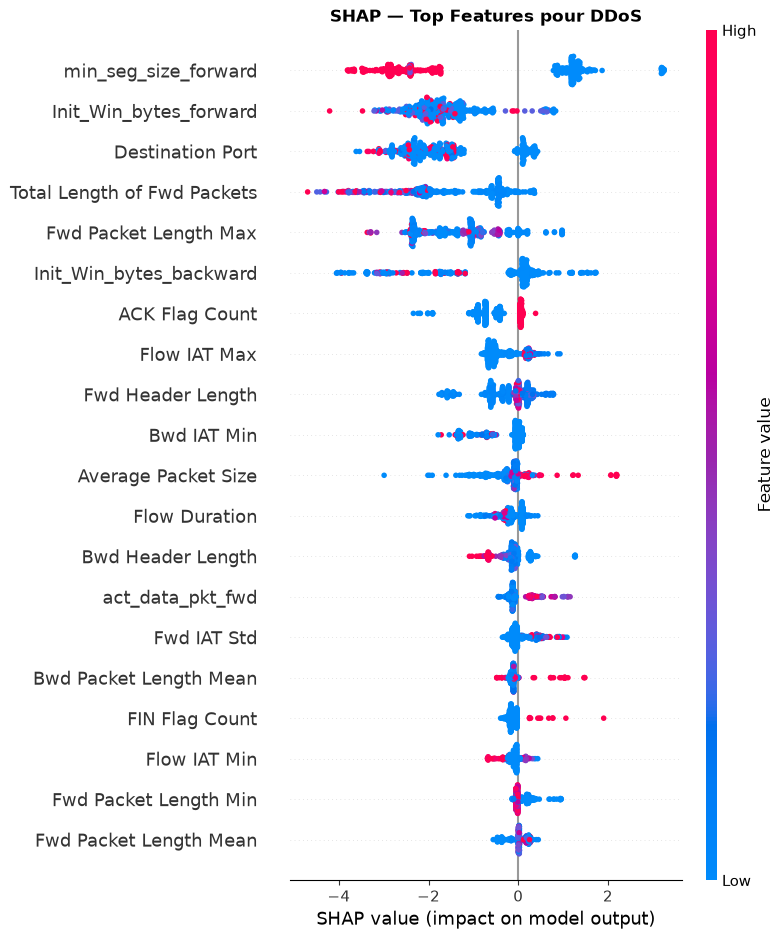

Graphique sauvegardé 


In [4]:
import matplotlib.pyplot as plt
import pandas as pd

# Charger le DataFrame original pour avoir les noms des features
df_clean = pd.read_csv('../data/cicids_clean.csv', nrows=1)
feature_names = [col for col in df_clean.columns if col != 'Attack Type']

class_names = le.classes_

# Summary plot pour DDoS
shap.summary_plot(
    shap_values[:, :, 2],  # classe DDoS (index 2)
    X_sample,
    feature_names=feature_names,
    show=False
)
plt.title("SHAP — Top Features pour DDoS", fontweight='bold')
plt.tight_layout()
plt.savefig('../notes/shap_ddos.png', dpi=100, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé ")

In [5]:
# Summary plot pour chaque type d'attaque
for i, class_name in enumerate(class_names):
    plt.figure(figsize=(10, 8))
    shap.summary_plot(
        shap_values[:, :, i],
        X_sample,
        feature_names=feature_names,
        show=False,
        plot_type="bar"
    )
    plt.title(f"SHAP — Top Features pour {class_name}", fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'../notes/shap_{class_name.replace(" ", "_")}.png', dpi=100, bbox_inches='tight')
    plt.close()
    print(f" {class_name} sauvegardé")

 Bots sauvegardé
 Brute Force sauvegardé
 DDoS sauvegardé
 DoS sauvegardé
 Normal Traffic sauvegardé
 Port Scanning sauvegardé
 Web Attacks sauvegardé


In [7]:
import sys
sys.path.append('../')
from utils.predictor import predict
import pandas as pd

# Charger un petit échantillon
df_clean = pd.read_csv('../data/cicids_clean.csv').sample(10, random_state=42)
feature_cols = [col for col in df_clean.columns if col != 'Attack Type']
df_test = df_clean[feature_cols]

# Tester le predictor
result = predict(df_test)

print(f"Total : {result['total']}")
print(f"Anomalies : {result['anomalies']}")
print(f"Normal : {result['normal']}")
print("\nDétails :")
for r in result['results']:
    print(f"  → {r['attack_type']} (confiance: {r['confidence']:.2%})")
    for f in r['top_features']:
        print(f"     {f['feature']} : {f['shap_value']}")

c:\Users\chouc\anaconda3\envs\cicids311\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\chouc\anaconda3\envs\cicids311\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.7.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Total : 10
Anomalies : 1
Normal : 9

Détails :
  → Normal Traffic (confiance: 100.00%)
     Destination Port : 4.1023
     Bwd Packets/s : 0.6519
     PSH Flag Count : 0.5223
  → Normal Traffic (confiance: 100.00%)
     Bwd Packet Length Min : 3.78
     Flow IAT Min : 0.814
     Init_Win_bytes_forward : 0.7202
  → Normal Traffic (confiance: 99.99%)
     Destination Port : 2.419
     Init_Win_bytes_forward : 0.7534
     Bwd Packet Length Min : -0.6718
  → Normal Traffic (confiance: 100.00%)
     Bwd Packet Length Min : 4.1118
     Init_Win_bytes_forward : 1.3
     Bwd Header Length : 0.4565
  → Normal Traffic (confiance: 100.00%)
     Destination Port : 3.6536
     Bwd Packets/s : 0.6879
     PSH Flag Count : 0.465
  → Normal Traffic (confiance: 99.99%)
     Init_Win_bytes_forward : 5.9202
     Destination Port : -1.0133
     PSH Flag Count : 0.459
  → Normal Traffic (confiance: 100.00%)
     Bwd Packet Length Min : 3.7948
     Init_Win_bytes_forward : 0.8937
     Init_Win_bytes_backwar

c:\Users\chouc\anaconda3\envs\cicids311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
